<a href="https://colab.research.google.com/github/skekek2/-/blob/main/10%EC%A3%BC%EC%B0%A8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 코로나 데이터 분석 프로젝트

In [29]:
# google colab에는 한글 폰트가 기본으로 깔려있지 않기 때문에 한글 폰트를 추가로 설치해주어야 합니다(최초 1회만) 런타임-런타임 다시 시작
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv           #폰트 리스트 갱신
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

In [31]:
font_list=fm.findSystemFonts(fontpaths=None, fontext='ttf')
#pass
font_list[:20]

['/usr/share/fonts/truetype/nanum/NanumGothicCoding.ttf',
 '/usr/share/fonts/truetype/nanum/NanumGothic.ttf',
 '/usr/share/fonts/truetype/nanum/NanumMyeongjo.ttf',
 '/usr/share/fonts/truetype/liberation/LiberationSerif-BoldItalic.ttf',
 '/usr/share/fonts/truetype/nanum/NanumGothicBold.ttf',
 '/usr/share/fonts/truetype/liberation/LiberationSans-BoldItalic.ttf',
 '/usr/share/fonts/truetype/liberation/LiberationMono-Bold.ttf',
 '/usr/share/fonts/truetype/nanum/NanumSquareRoundR.ttf',
 '/usr/share/fonts/truetype/nanum/NanumSquareB.ttf',
 '/usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf',
 '/usr/share/fonts/truetype/liberation/LiberationMono-Italic.ttf',
 '/usr/share/fonts/truetype/nanum/NanumBarunGothicBold.ttf',
 '/usr/share/fonts/truetype/humor-sans/Humor-Sans.ttf',
 '/usr/share/fonts/truetype/liberation/LiberationSerif-Regular.ttf',
 '/usr/share/fonts/truetype/nanum/NanumSquareR.ttf',
 '/usr/share/fonts/truetype/liberation/LiberationSansNarrow-Regular.ttf',
 '/usr/share/fon

In [32]:
#@title

plt.rc('font', family='NanumBarunGothic')  #rc를 통해 폰트 설정

In [33]:
pass
pass
pass
#사용할 폰트가 있는 경로 지정
path='/usr/share/fonts/truetype/nanum/NanumMyeongjo.ttf'
path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
#font_manager의 FontProperties에 폰트 경로를 전달하여 폰트이름을 얻어옴.
font_name = fm.FontProperties(fname=path, size=10).get_name() #폰트 이름 얻어오기
plt.rc('font', family=font_name)
#fm._rebuild()

 `서울시 코로나19 확진자 현황` 데이터(원본 데이터에서 이상치 처리를 수행함)를 바탕으로 **탐색적 데이터 분석(EDA)**을 수행해 보겠습니다.

데이터 출처: https://www.data.go.kr/tcs/dss/selectFileDataDetailView.do?publicDataPk=15063273

이번 실습에서 EDA 과정은 다음과 같은 과정으로 이루어져 있습니다.

1. **데이터 읽기:** 코로나 데이터를 불러오고 Dataframe 구조를 확인

2. **데이터 정제:** 비어 있는 데이터 또는 쓸모 없는 데이터를 삭제

3. **데이터 시각화:** 각 변수 별로 추가적인 정제 또는 feature engineering 과정을 거치고 시각화를 통하여 데이터의 특성 파악

## 1. 데이터 읽기

`pandas`를 사용하여 데이터를 읽고 어떠한 데이터가 저장되어 있는지 확인합니다.

In [34]:
from google.colab import drive

# Google Drive 패키지 불러오기
drive.mount ('/gdrive', force_remount=True)


Mounted at /gdrive


In [35]:

import os




In [37]:
os.getcwd()

OSError: [Errno 107] Transport endpoint is not connected

In [38]:
!pwd

shell-init: error retrieving current directory: getcwd: cannot access parent directories: Transport endpoint is not connected
pwd: error retrieving current directory: getcwd: cannot access parent directories: Transport endpoint is not connected


In [39]:
os.chdir('/gdrive/My Drive/Colab Notebooks/10')

In [40]:
!pwd

/gdrive/MyDrive/Colab Notebooks/10


In [41]:
!ls

10주차.ipynb  seoul_corona.csv	seoul_info.csv


In [42]:
# pd.read_csv를 통하여 dataframe 형태로 읽어옵니다.
df_corona = pd.read_csv("seoul_corona.csv")

In [43]:
df_corona.head(10)

,연번,확진달,확진일,환자번호,국적,환자정보,지역,여행력,접촉력,조치사항,상태,이동경로,등록일,수정일,노출여부
0,5748,10,21,25530,NaN,NaN,양천구,NaN,감염경로 조사중,NaN,NaN,NaN,2020-10-22 10:58,2020-10-22 10:58,Y
1,5747,10,21,25528,NaN,NaN,강동구,NaN,강남서초 지인모임,NaN,NaN,NaN,2020-10-22 10:58,2020-10-22 10:58,Y
2,5746,10,21,25525,NaN,NaN,강남구,NaN,기타 확진자 접촉,NaN,NaN,NaN,2020-10-22 10:58,2020-10-22 10:58,Y
3,5745,10,21,25517,NaN,NaN,관악구,NaN,감염경로 조사중,NaN,NaN,NaN,2020-10-22 10:58,2020-10-22 10:58,Y
4,5744,10,21,25504,NaN,NaN,관악구,NaN,기타 확진자 접촉,NaN,NaN,NaN,2020-10-22 10:58,2020-10-22 10:58,Y
5,5743,10,21,25505,NaN,NaN,구로구,NaN,감염경로 조사중,NaN,NaN,NaN,2020-10-22 10:58,2020-10-22 15:44,Y
6,5742,10,21,25455,NaN,NaN,관악구,NaN,관악구 삼모스포렉스Ⅱ,NaN,NaN,NaN,2020-10-22 10:58,2020-10-22 10:58,Y
7,5741,10,21,25456,NaN,NaN,관악구,NaN,관악구 삼모스포렉스Ⅱ,NaN,NaN,NaN,2020-10-22 10:58,2020-10-22 10:58,Y
8,5740,10,21,25457,NaN,NaN,관악구,NaN,관악구 삼모스포렉스Ⅱ,NaN,NaN,NaN,2020-10-22 10:58,2020-10-22 10:58,Y
9,5739,10,21,25466,NaN,NaN,관악구,NaN,관악구 삼모스포렉스Ⅱ,NaN,NaN,NaN,2020-10-22 10:58,2020-10-22 10:58,Y


In [44]:
df_corona. tail()

,연번,확진달,확진일,환자번호,국적,환자정보,지역,여행력,접촉력,조치사항,상태,이동경로,등록일,수정일,노출여부
5743,5,1,31,9,NaN,NaN,성북구,NaN,#5 접촉,NaN,퇴원,이동경로 공개기간 경과,2020-10-22 10:58,2020-10-23 9:00,Y
5744,4,1,30,7,NaN,NaN,마포구,중국 우한시,해외 접촉,NaN,퇴원,이동경로 공개기간 경과,2020-10-22 10:58,2020-10-23 9:00,Y
5745,3,1,30,6,NaN,NaN,종로구,NaN,#3 접촉,NaN,퇴원,이동경로 공개기간 경과,2020-10-22 10:58,2020-10-23 9:00,Y
5746,2,1,30,5,NaN,NaN,중랑구,중국 우한시,해외 접촉,NaN,퇴원,이동경로 공개기간 경과,2020-10-22 10:58,2020-10-23 9:00,Y
5747,1,1,24,2,NaN,NaN,강서구,중국 우한시,해외 접촉,NaN,퇴원,이동경로 공개기간 경과,2020-10-22 10:58,2020-10-23 9:00,Y


In [45]:
# 상위 5개 데이터를 출력합니다.
df_corona.head()


,연번,확진달,확진일,환자번호,국적,환자정보,지역,여행력,접촉력,조치사항,상태,이동경로,등록일,수정일,노출여부
0,5748,10,21,25530,NaN,NaN,양천구,NaN,감염경로 조사중,NaN,NaN,NaN,2020-10-22 10:58,2020-10-22 10:58,Y
1,5747,10,21,25528,NaN,NaN,강동구,NaN,강남서초 지인모임,NaN,NaN,NaN,2020-10-22 10:58,2020-10-22 10:58,Y
2,5746,10,21,25525,NaN,NaN,강남구,NaN,기타 확진자 접촉,NaN,NaN,NaN,2020-10-22 10:58,2020-10-22 10:58,Y
3,5745,10,21,25517,NaN,NaN,관악구,NaN,감염경로 조사중,NaN,NaN,NaN,2020-10-22 10:58,2020-10-22 10:58,Y
4,5744,10,21,25504,NaN,NaN,관악구,NaN,기타 확진자 접촉,NaN,NaN,NaN,2020-10-22 10:58,2020-10-22 10:58,Y


In [46]:
# dataframe 정보를 요약하여 출력합니다.
df_corona. info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5748 entries, 0 to 5747
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   연번      5748 non-null   int64  
 1   확진달     5748 non-null   int64  
 2   확진일     5748 non-null   int64  
 3   환자번호    5748 non-null   int64  
 4   국적      0 non-null      float64
 5   환자정보    0 non-null      float64
 6   지역      5748 non-null   object 
 7   여행력     458 non-null    object 
 8   접촉력     5748 non-null   object 
 9   조치사항    0 non-null      float64
 10  상태      5357 non-null   object 
 11  이동경로    5520 non-null   object 
 12  등록일     5748 non-null   object 
 13  수정일     5748 non-null   object 
 14  노출여부    5748 non-null   object 
dtypes: float64(3), int64(4), object(8)
memory usage: 673.7+ KB


## 2. 데이터 정제

데이터를 읽고 확인했다면 결측값(missing data), 이상치(outlier)를 처리하는 데이터 정제 과정을 수행하여 봅시다.

#### 2.1 비어있는 column 지우기

`df_corona.info()` 코드를 통하여 `국적`, `환자정보`, `조치사항` 에 해당하는 데이터가 존재하지 않는 것을 알 수 있습니다.

`dataframe.drop()`를 사용하여 불필요한 `국적`, `환자정보`, `조치사항` 의 column 데이터를 삭제하고 이 dataframe을 `df_corona`에 저장해 봅시다.

In [47]:
df_corona.drop(columns=['국적'])

,연번,확진달,확진일,환자번호,환자정보,지역,여행력,접촉력,조치사항,상태,이동경로,등록일,수정일,노출여부
0,5748,10,21,25530,NaN,양천구,NaN,감염경로 조사중,NaN,NaN,NaN,2020-10-22 10:58,2020-10-22 10:58,Y
1,5747,10,21,25528,NaN,강동구,NaN,강남서초 지인모임,NaN,NaN,NaN,2020-10-22 10:58,2020-10-22 10:58,Y
2,5746,10,21,25525,NaN,강남구,NaN,기타 확진자 접촉,NaN,NaN,NaN,2020-10-22 10:58,2020-10-22 10:58,Y
3,5745,10,21,25517,NaN,관악구,NaN,감염경로 조사중,NaN,NaN,NaN,2020-10-22 10:58,2020-10-22 10:58,Y
4,5744,10,21,25504,NaN,관악구,NaN,기타 확진자 접촉,NaN,NaN,NaN,2020-10-22 10:58,2020-10-22 10:58,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5743,5,1,31,9,NaN,성북구,NaN,#5 접촉,NaN,퇴원,이동경로 공개기간 경과,2020-10-22 10:58,2020-10-23 9:00,Y
5744,4,1,30,7,NaN,마포구,중국 우한시,해외 접촉,NaN,퇴원,이동경로 공개기간 경과,2020-10-22 10:58,2020-10-23 9:00,Y
5745,3,1,30,6,NaN,종로구,NaN,#3 접촉,NaN,퇴원,이동경로 공개기간 경과,2020-10-22 10:58,2020-10-23 9:00,Y
5746,2,1,30,5,NaN,중랑구,중국 우한시,해외 접촉,NaN,퇴원,이동경로 공개기간 경과,2020-10-22 10:58,2020-10-23 9:00,Y


In [48]:
df_corona. info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5748 entries, 0 to 5747
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   연번      5748 non-null   int64  
 1   확진달     5748 non-null   int64  
 2   확진일     5748 non-null   int64  
 3   환자번호    5748 non-null   int64  
 4   국적      0 non-null      float64
 5   환자정보    0 non-null      float64
 6   지역      5748 non-null   object 
 7   여행력     458 non-null    object 
 8   접촉력     5748 non-null   object 
 9   조치사항    0 non-null      float64
 10  상태      5357 non-null   object 
 11  이동경로    5520 non-null   object 
 12  등록일     5748 non-null   object 
 13  수정일     5748 non-null   object 
 14  노출여부    5748 non-null   object 
dtypes: float64(3), int64(4), object(8)
memory usage: 673.7+ KB


In [49]:
pass

In [50]:
df_coronal=df_corona.drop(columns =['국적','환자정보','조치사항'])

In [51]:
df_coronal.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5748 entries, 0 to 5747
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   연번      5748 non-null   int64 
 1   확진달     5748 non-null   int64 
 2   확진일     5748 non-null   int64 
 3   환자번호    5748 non-null   int64 
 4   지역      5748 non-null   object
 5   여행력     458 non-null    object
 6   접촉력     5748 non-null   object
 7   상태      5357 non-null   object
 8   이동경로    5520 non-null   object
 9   등록일     5748 non-null   object
 10  수정일     5748 non-null   object
 11  노출여부    5748 non-null   object
dtypes: int64(4), object(8)
memory usage: 539.0+ KB


In [52]:
# drop 함수를 사용하여 국적, 환자정보, 조치사항 coulmn 데이터를 삭제합니다.
pass
#방법1 df_corona=df_corona.drop(columns=['국적','환자정보','조치사항'])
df_corona.drop(columns=['국적','환자정보','조치사항'], inplace=True)

In [53]:
df_corona. info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5748 entries, 0 to 5747
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   연번      5748 non-null   int64 
 1   확진달     5748 non-null   int64 
 2   확진일     5748 non-null   int64 
 3   환자번호    5748 non-null   int64 
 4   지역      5748 non-null   object
 5   여행력     458 non-null    object
 6   접촉력     5748 non-null   object
 7   상태      5357 non-null   object
 8   이동경로    5520 non-null   object
 9   등록일     5748 non-null   object
 10  수정일     5748 non-null   object
 11  노출여부    5748 non-null   object
dtypes: int64(4), object(8)
memory usage: 539.0+ KB


In [54]:
df_corona.head()

,연번,확진달,확진일,환자번호,지역,여행력,접촉력,상태,이동경로,등록일,수정일,노출여부
0,5748,10,21,25530,양천구,NaN,감염경로 조사중,NaN,NaN,2020-10-22 10:58,2020-10-22 10:58,Y
1,5747,10,21,25528,강동구,NaN,강남서초 지인모임,NaN,NaN,2020-10-22 10:58,2020-10-22 10:58,Y
2,5746,10,21,25525,강남구,NaN,기타 확진자 접촉,NaN,NaN,2020-10-22 10:58,2020-10-22 10:58,Y
3,5745,10,21,25517,관악구,NaN,감염경로 조사중,NaN,NaN,2020-10-22 10:58,2020-10-22 10:58,Y
4,5744,10,21,25504,관악구,NaN,기타 확진자 접촉,NaN,NaN,2020-10-22 10:58,2020-10-22 10:58,Y


In [129]:
# drop 함수를 사용하여 국적, 환자정보, 조치사항 coulmn 데이터를 삭제합니다.
# errors='ignore'를 추가하면 이미 지워졌거나 컬럼이 없어도 에러 없이 넘어갑니다.
df_corona.drop(columns=['국적', '환자정보', '조치사항'], inplace=True, errors='ignore')

In [56]:
df_corona.head()

,연번,확진달,확진일,환자번호,지역,여행력,접촉력,상태,이동경로,등록일,수정일,노출여부
0,5748,10,21,25530,양천구,NaN,감염경로 조사중,NaN,NaN,2020-10-22 10:58,2020-10-22 10:58,Y
1,5747,10,21,25528,강동구,NaN,강남서초 지인모임,NaN,NaN,2020-10-22 10:58,2020-10-22 10:58,Y
2,5746,10,21,25525,강남구,NaN,기타 확진자 접촉,NaN,NaN,2020-10-22 10:58,2020-10-22 10:58,Y
3,5745,10,21,25517,관악구,NaN,감염경로 조사중,NaN,NaN,2020-10-22 10:58,2020-10-22 10:58,Y
4,5744,10,21,25504,관악구,NaN,기타 확진자 접촉,NaN,NaN,2020-10-22 10:58,2020-10-22 10:58,Y


In [57]:
# 정제 처리된 dataframe 정보를 출력합니다.
pass

## 3. 데이터 시각화

결측값을 처리한 `df_corona` 데이터를 바탕으로 각 column의 변수별로 어떠한 데이터 분포를 하고 있는지 시각화를 통하여 알아봅시다.

### 3.1 확진달 & 확진일

`확진달`과 `확진일` 데이터를 간단히 출력하여 어떠한 데이터가 있는지 확인해 보겠습니다.

In [58]:
df_corona['확진달']

,확진달
0,10
1,10
2,10
3,10
4,10
...,...
5743,1
5744,1
5745,1
5746,1


In [59]:
df_corona['확진일']

,확진일
0,21
1,21
2,21
3,21
4,21
...,...
5743,31
5744,30
5745,30
5746,30


In [60]:
df_corona[['확진달', '확진일']]

,확진달,확진일
0,10,21
1,10,21
2,10,21
3,10,21
4,10,21
...,...,...
5743,1,31
5744,1,30
5745,1,30
5746,1,30


#### 3.1.1. 월별 확진자 수 출력

월별 확진자 수를 막대그래프로 출력해 보겠습니다.

In [61]:
pass

/tmp/ipykernel_5339/886759274.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='확진달', data=df_corona, palette="Set2")


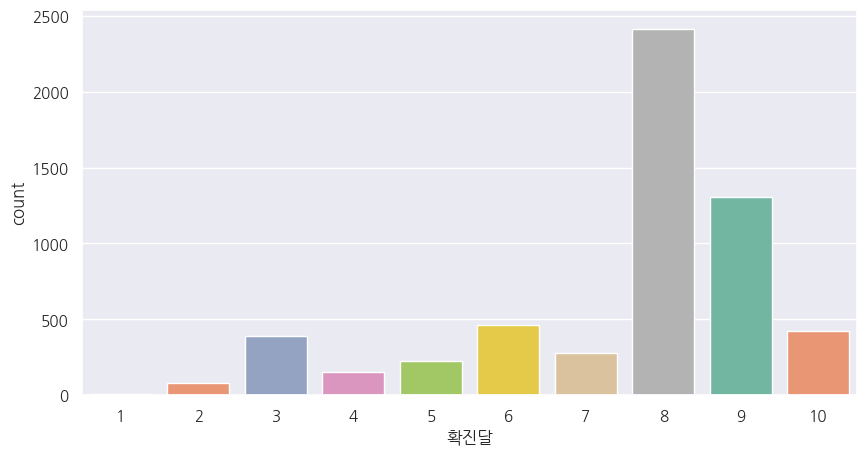

In [62]:
path ='/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
#font_manager의 FontProperties에 폰트 경로를 전달하여 폰트이름을 얻어옴.
font_name = fm.FontProperties(fname=path, size=10).get_name() #폰트 이름 얻어오기
plt.figure(figsize=(10,5))
# seaborn의 countplot 함수를 사용하여 출력합니다.
# 한글 출력을 위해서 폰트 옵션을 설정합니다.
sns.set (font=font_name,
         rc={"axes.unicode_minus":False},
         style='darkgrid')
ax = sns.countplot(x='확진달', data=df_corona, palette="Set2")

# 그래프의 사이즈들 조절합니다.
#사용할 폰트가 있는 경로 지정

In [63]:
# value_counts()는 각 데이터를 세어서 내림차순으로 정리하는 함수입니다.
pass
df_corona[ '확진달'].value_counts()

,count
확진달,
8,2416
9,1304
6,460
10,425
3,391
7,281
5,228
4,156
2,80


<Axes: xlabel='확진달'>

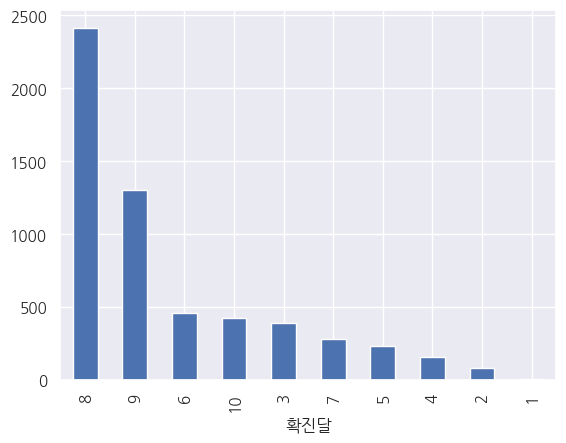

In [64]:
# series의 plot 함수를 사용한 출력 방법도 있습니다.
pass
df_corona[ '확진달'].value_counts().plot(kind='bar')

#### 3.1.2. 8월 일별 확진자 수 출력

월별 확진자 수를 출력해보면 알 수 있듯이 8월에 확진자 수가 가장 많았습니다.

이번엔 8월 동안 확진자 수가 어떻게 늘었는지 일별 확진자 수를 막대그래프로 출력해 봅시다.

In [65]:
df_corona[ '확진달' ] == 8

,확진달
0,False
1,False
2,False
3,False
4,False
...,...
5743,False
5744,False
5745,False
5746,False


In [66]:
df_corona[df_coronal ['확진달'] == 8]

,연번,확진달,확진일,환자번호,지역,여행력,접촉력,상태,이동경로,등록일,수정일,노출여부
1271,4477,8,31,20132,타시도,NaN,감염경로 조사중,퇴원,이동경로 공개기간 경과,2020-10-22 10:58,2020-10-23 9:00,Y
1272,4476,8,25,17968,타시도,NaN,성북구 사랑제일교회 관련,NaN,이동경로 공개기간 경과,2020-10-22 10:58,2020-10-23 9:00,Y
1273,4475,8,26,18821,타시도,NaN,타시도 확진자 접촉,퇴원,이동경로 공개기간 경과,2020-10-22 10:58,2020-10-23 9:00,Y
1274,4474,8,27,18818,타시도,NaN,기타 확진자 접촉,퇴원,이동경로 공개기간 경과,2020-10-22 10:58,2020-10-23 9:00,Y
1504,4244,8,30,20116,타시도,NaN,감염경로 조사중,퇴원,이동경로 공개기간 경과,2020-10-22 10:58,2020-10-23 9:00,Y
...,...,...,...,...,...,...,...,...,...,...,...,...
4140,1608,8,2,14382,용산구,일본,해외 접촉 추정,퇴원,이동경로 공개기간 경과,2020-10-22 10:58,2020-10-23 9:00,Y
4141,1607,8,1,14364,양천구,NaN,송파구 확진자 접촉,퇴원,이동경로 공개기간 경과,2020-10-22 10:58,2020-10-23 9:00,Y
4142,1606,8,1,14362,종로구,NaN,종로구 지인모임 신명투자,퇴원,이동경로 공개기간 경과,2020-10-22 10:58,2020-10-23 9:00,Y
4144,1604,8,1,14366,강서구,NaN,강서구 요양시설관련,퇴원,이동경로 공개기간 경과,2020-10-22 10:58,2020-10-23 9:00,Y


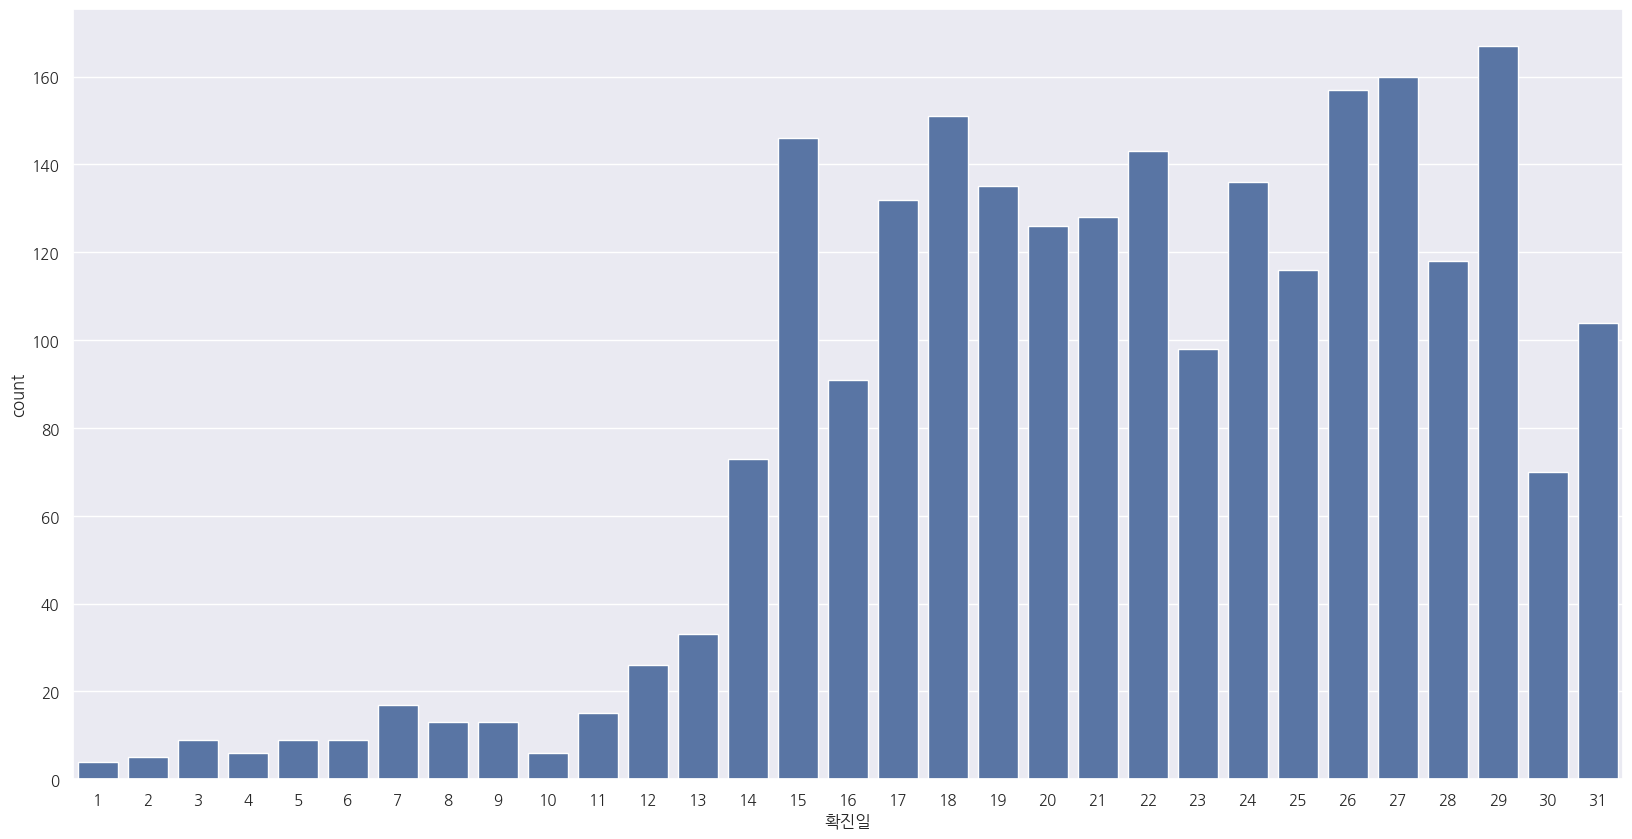

In [67]:
# seaborn의 countplot 함수를 사용하여 출력합니다. rocket_r
plt.figure(figsize=(20,10))
ax =sns.countplot(x='확진일',data=df_corona[df_corona['확진달'] == 8])

/tmp/ipykernel_5339/2206853423.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="확진일", data=df_corona[df_corona['확진달'] == 8], palette="rocket_r")


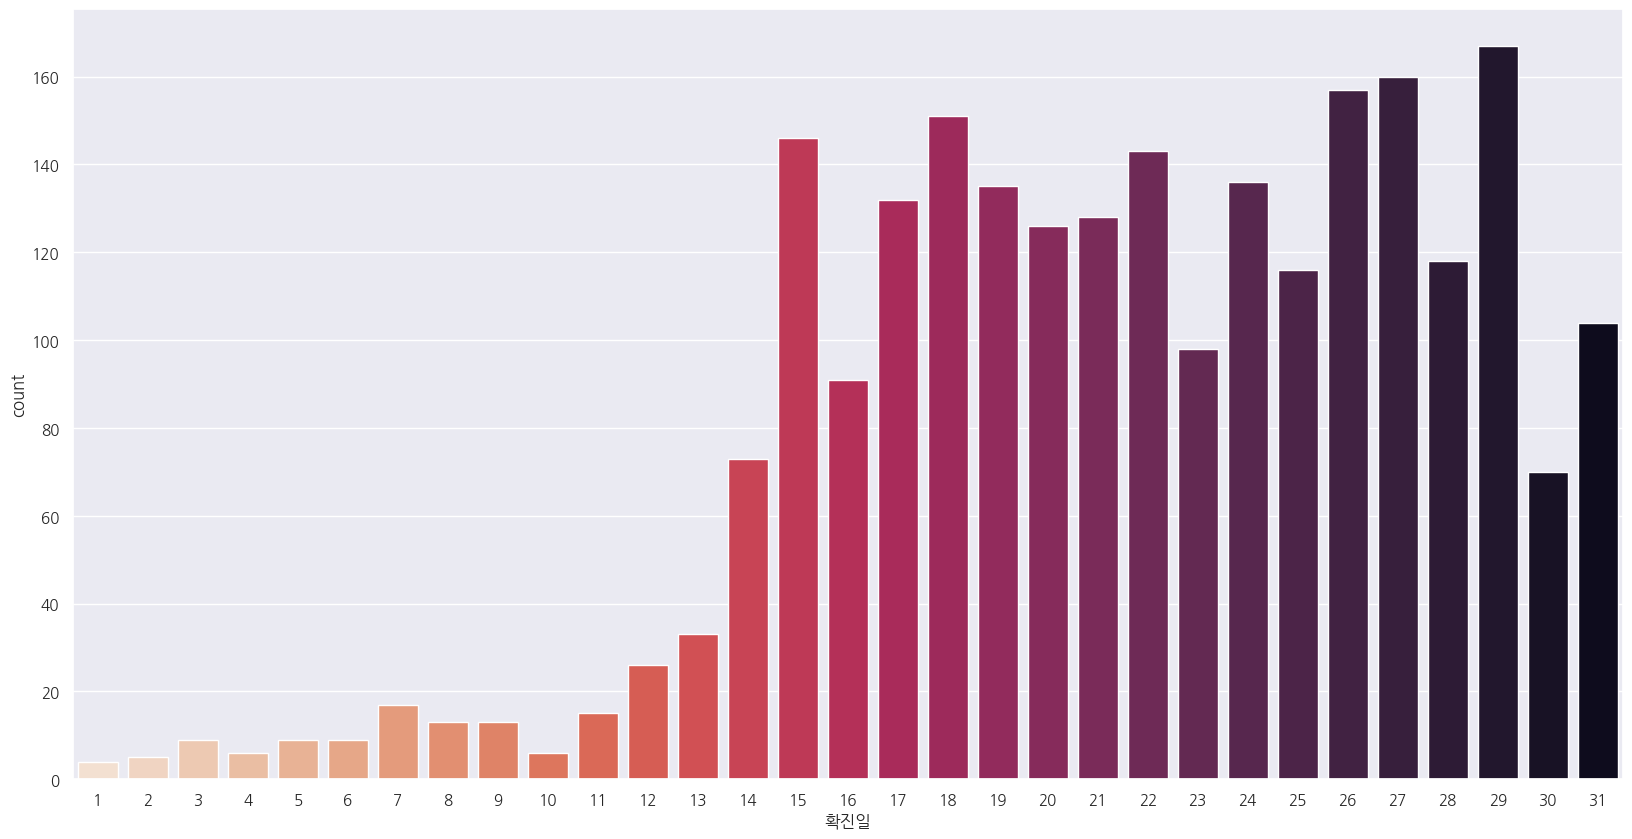

In [68]:
# seaborn의 countplot 함수를 사용하여 출력합니다.
plt.figure(figsize=(20,10))
ax = sns.countplot(x="확진일", data=df_corona[df_corona['확진달'] == 8], palette="rocket_r")

/tmp/ipykernel_5339/894101415.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="확진달", data=df_corona[df_corona['확진일'] == 1], palette="rocket_r")


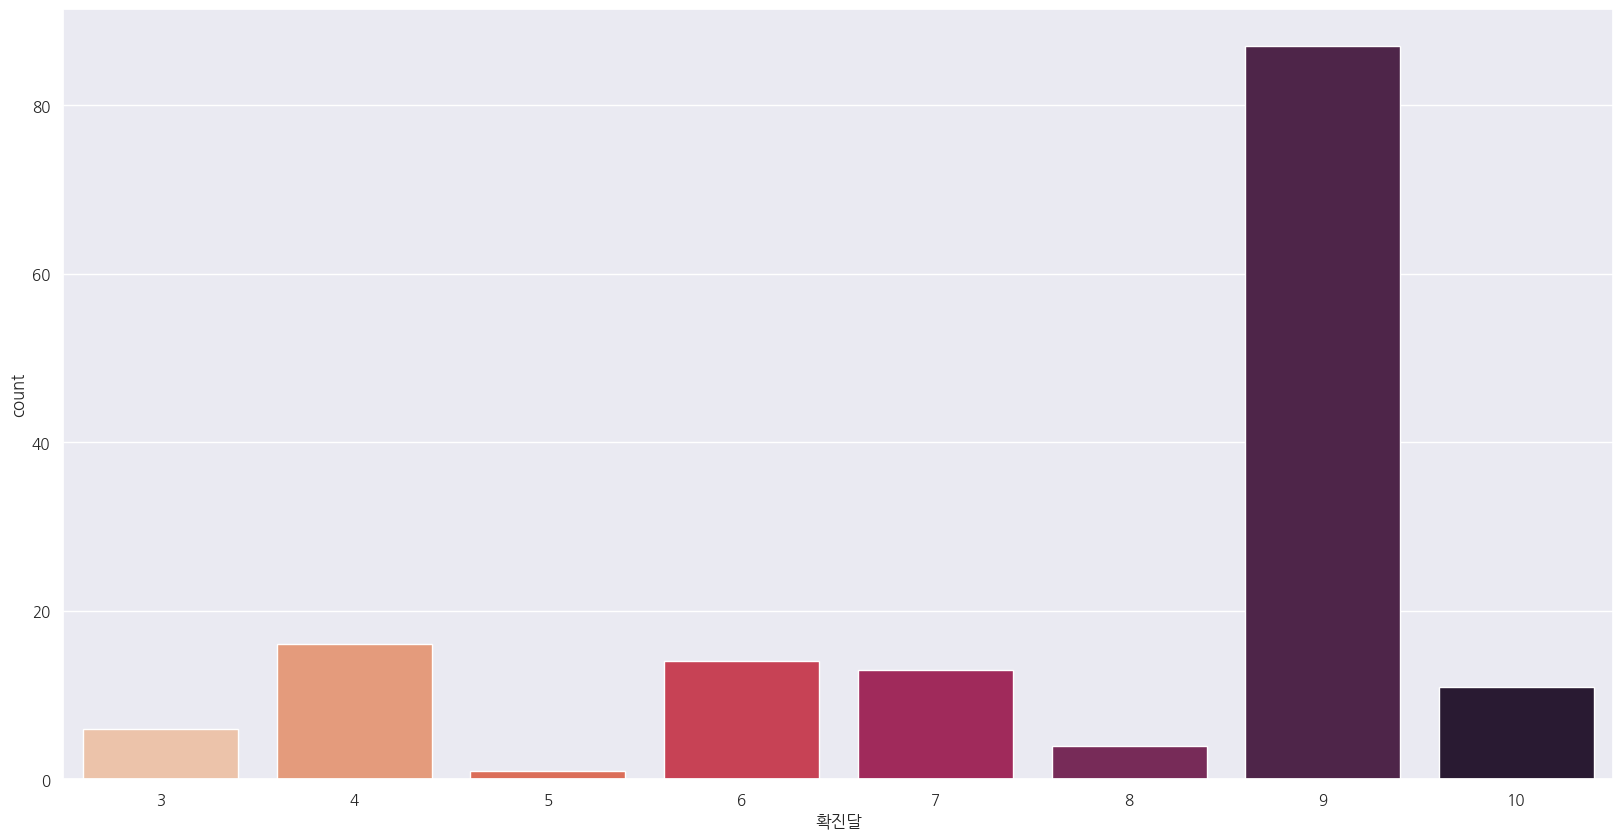

In [69]:
# seaborn의 countplot 함수를 사용하여 출력합니다.
plt.figure(figsize=(20,10))
ax = sns.countplot(x="확진달", data=df_corona[df_corona['확진일'] == 1], palette="rocket_r")

In [70]:
#-----------------------------------------------------------------------------------------------------

### 3.2. 지역

`지역` 데이터를 간단히 출력해보면 `oo구` 형태의 문자열 데이터임을 알 수 있습니다.

In [71]:
set(df_corona['지역'])

{'강남구',
 '강동구',
 '강북구',
 '강서구',
 '관악구',
 '광진구',
 '구로구',
 '금천구',
 '기타',
 '노원구',
 '도봉구',
 '동대문구',
 '동작구',
 '마포구',
 '서대문구',
 '서초구',
 '성동구',
 '성북구',
 '송파구',
 '양천구',
 '영등포구',
 '용산구',
 '은평구',
 '종로구',
 '중구',
 '중랑구',
 '타시도'}

In [72]:
len(set(df_corona['지역']))

27

In [73]:
pass
df_corona[ '지역'].value_counts()

,count
지역,
관악구,452
송파구,361
성북구,344
타시도,331
노원구,323
강남구,296
강서구,295
은평구,259
동작구,254


#### 3.2.1. 지역별 확진자 수 출력

이번에는 지역별로 확진자가 얼마나 있는지 막대그래프로 출력해 봅시다.

In [74]:
pass
pass

In [75]:
local=list(df_corona['지역'].value_counts().index)

In [76]:
local

['관악구',
 '송파구',
 '성북구',
 '타시도',
 '노원구',
 '강남구',
 '강서구',
 '은평구',
 '동작구',
 '도봉구',
 '서초구',
 '중랑구',
 '영등포구',
 '강동구',
 '구로구',
 '양천구',
 '마포구',
 '동대문구',
 '강북구',
 '용산구',
 '광진구',
 '서대문구',
 '성동구',
 '기타',
 '금천구',
 '종로구',
 '중구']

/tmp/ipykernel_5339/3501118412.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="지역", data=df_corona, palette="Set2")


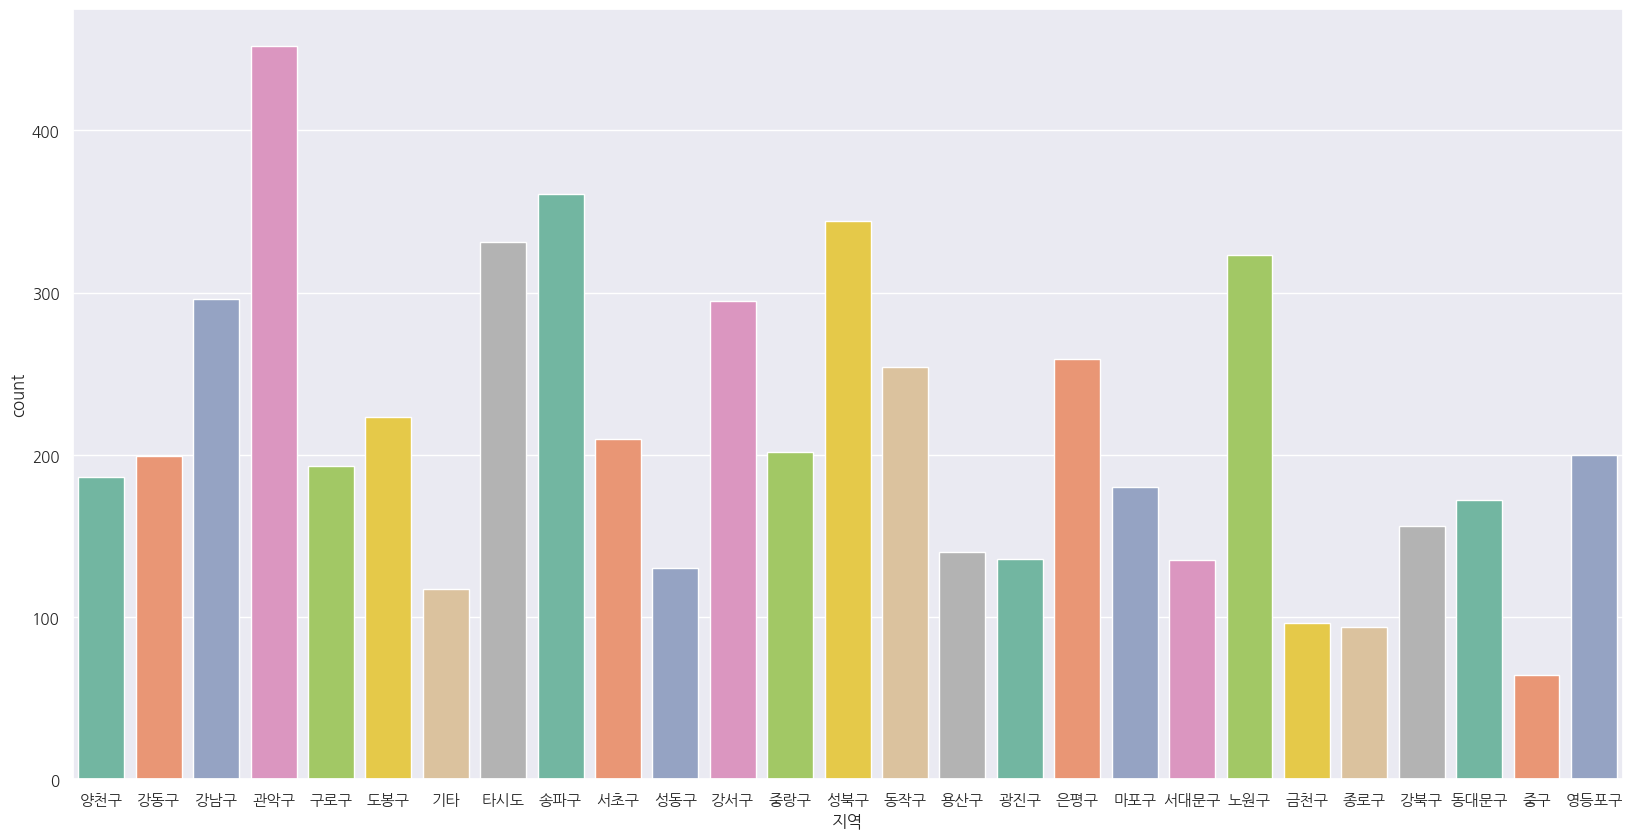

In [77]:
plt.figure(figsize=(20,10))
#ax=None

ax = sns.countplot(x="지역", data=df_corona, palette="Set2")


/tmp/ipykernel_5339/3619480455.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="지역", data=df_corona, palette="Set2", order=local)


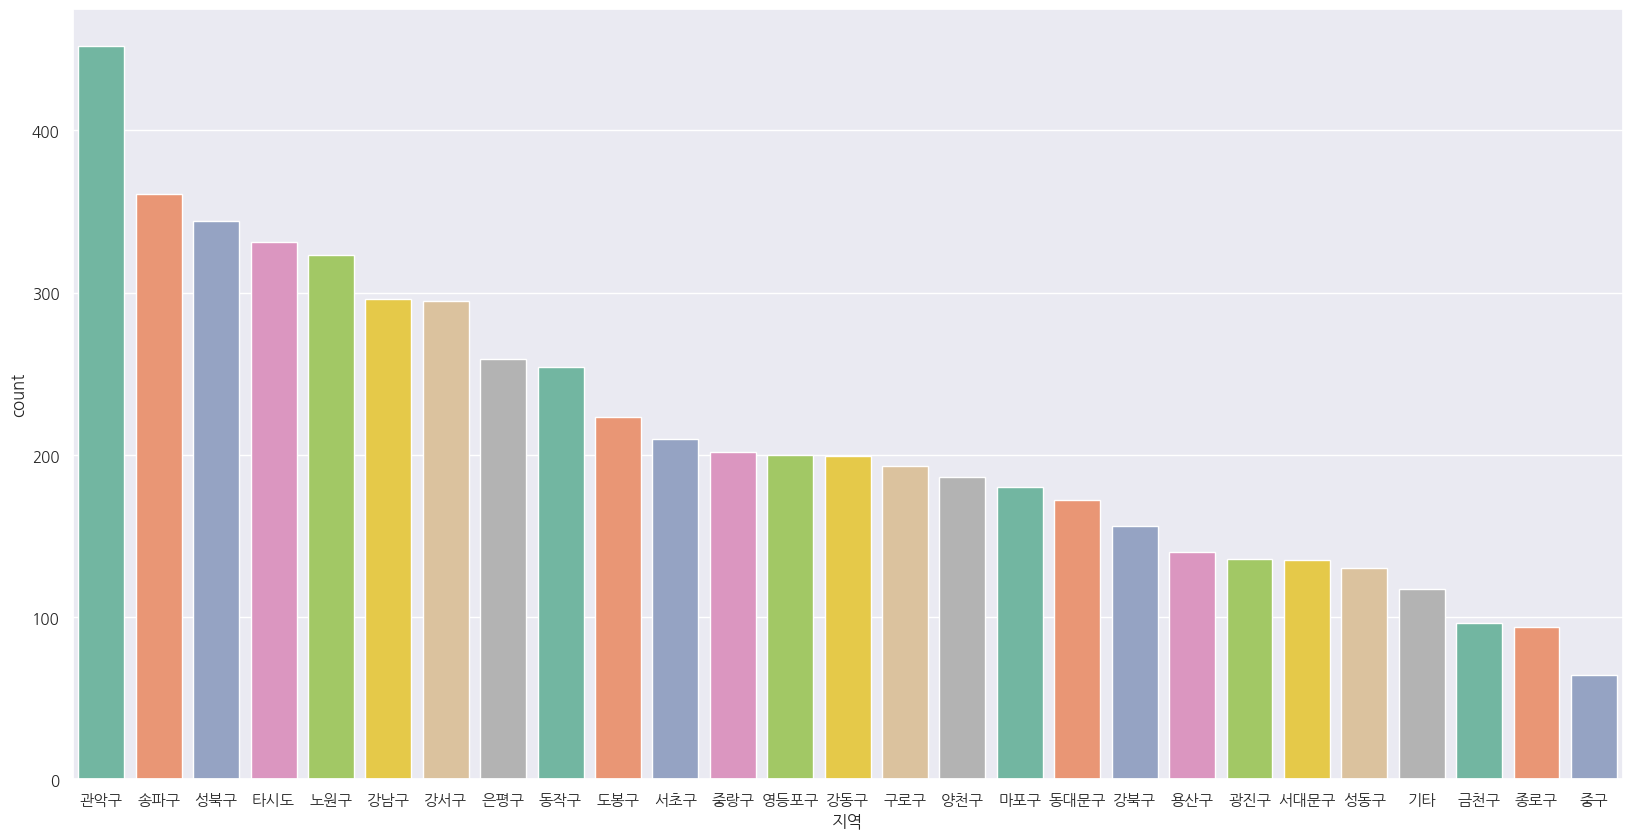

In [78]:
plt.figure(figsize=(20,10))
ax = sns.countplot(x="지역", data=df_corona, palette="Set2", order=local)

#### 3.2.2. 8월달 지역별 확진자 수 출력

감염자가 많았던 8월에는 지역별로 확진자가 어떻게 분포되어 있는지 막대그래프로 출력해 봅시다.

In [79]:
# 논리연산을 이용한 조건을 다음과 같이 사용하면 해당 조건에 맞는 데이터를 출력할 수 있습니다.
pass
df_corona[ '지역'][df_corona[ '확진달'] == 8].value_counts()

,count
지역,
성북구,244
노원구,191
송파구,161
타시도,143
은평구,121
강서구,116
동작구,110
관악구,109
중랑구,104


In [80]:
pass

/tmp/ipykernel_5339/15102618.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="지역", data=df_corona[df_corona['확진달'] == 8], palette="CMRmap")


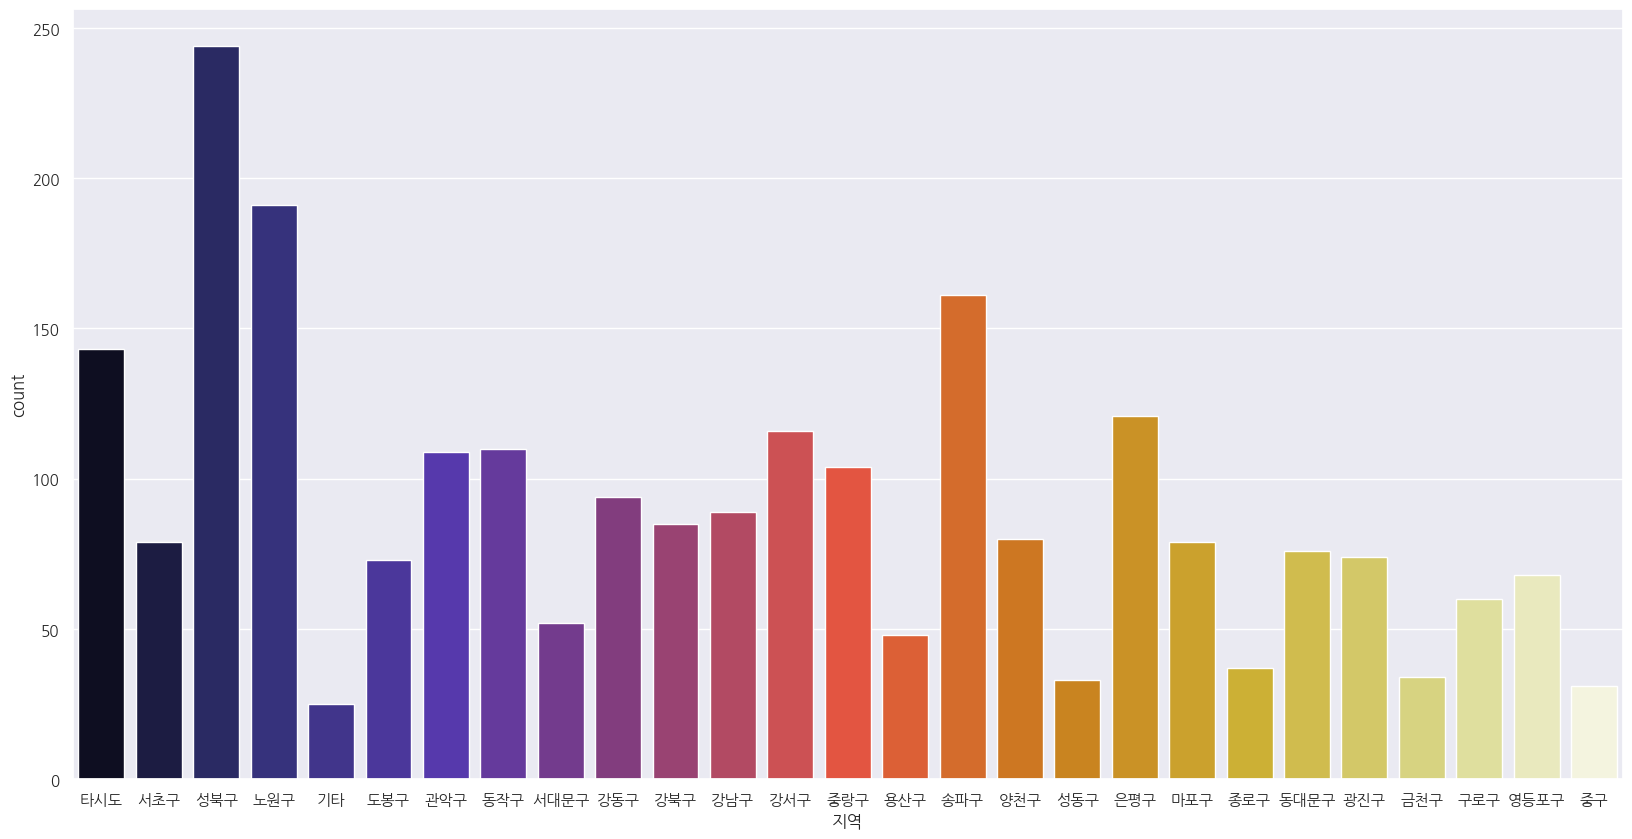

In [81]:
# 그래프를 출력합니다.
plt.figure(figsize=(20,10))
#ax=pass
ax = sns.countplot(x="지역", data=df_corona[df_corona['확진달'] == 8], palette="CMRmap")

#### 3.2.3. 월별 관악구 확진자 수 출력

이번에는 확진자가 가장 많았던 관악구 내의 확진자 수가 월별로 어떻게 증가했는지 그 분포를 막대그래프로 출력해 봅시다.

In [82]:
# 해당 column을 지정하여 series 형태로 출력할 수 있습니다.
pass
df_corona['확진달'][df_corona['지역'] == '관악구'].value_counts()
#pass

,count
확진달,
9,135
8,109
10,63
6,59
3,30
7,27
5,16
4,9
2,4


In [83]:
pass

/tmp/ipykernel_5339/1903817562.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='확진달', data=df_corona[df_corona['지역'] == '관악구'], palette="Set2")


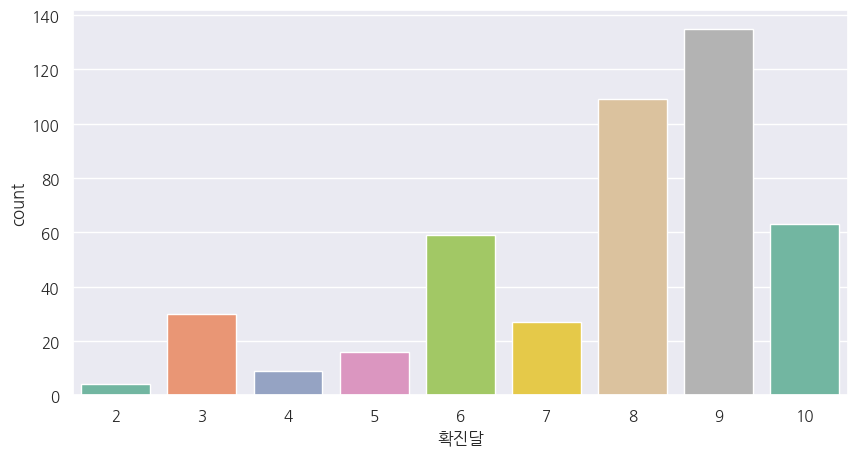

In [84]:
# 그래프를 출력합니다.
plt.figure(figsize=(10,5))
pass
ax = sns.countplot(x='확진달', data=df_corona[df_corona['지역'] == '관악구'], palette="Set2")

In [85]:
df_corona. info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5748 entries, 0 to 5747
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   연번      5748 non-null   int64 
 1   확진달     5748 non-null   int64 
 2   확진일     5748 non-null   int64 
 3   환자번호    5748 non-null   int64 
 4   지역      5748 non-null   object
 5   여행력     458 non-null    object
 6   접촉력     5748 non-null   object
 7   상태      5357 non-null   object
 8   이동경로    5520 non-null   object
 9   등록일     5748 non-null   object
 10  수정일     5748 non-null   object
 11  노출여부    5748 non-null   object
dtypes: int64(4), object(8)
memory usage: 539.0+ KB


In [86]:
df_corona[(df_corona['확진달'] == 8) & (df_corona['지역'] == '성북구')]

,연번,확진달,확진일,환자번호,지역,여행력,접촉력,상태,이동경로,등록일,수정일,노출여부
1643,4105,8,31,20465,성북구,NaN,기타 확진자 접촉,퇴원,이동경로 공개기간 경과,2020-10-22 10:58,2020-10-23 9:00,Y
1726,4022,8,31,20328,성북구,NaN,성북구 사랑제일교회 관련,퇴원,이동경로 공개기간 경과,2020-10-22 10:58,2020-10-23 9:00,Y
1727,4021,8,31,20324,성북구,NaN,감염경로 조사중,퇴원,이동경로 공개기간 경과,2020-10-22 10:58,2020-10-23 9:00,Y
1814,3934,8,31,20137,성북구,NaN,성북구 요양시설,퇴원,이동경로 공개기간 경과,2020-10-22 10:58,2020-10-23 9:00,Y
1815,3933,8,31,20157,성북구,NaN,성북구 요양시설,사망,이동경로 공개기간 경과,2020-10-22 10:58,2020-10-23 9:00,Y
...,...,...,...,...,...,...,...,...,...,...,...,...
4091,1657,8,7,14545,성북구,NaN,확인 중,퇴원,이동경로 공개기간 경과,2020-10-22 10:58,2020-10-23 9:00,Y
4105,1643,8,6,14512,성북구,홍콩,해외 접촉 추정,퇴원,이동경로 공개기간 경과,2020-10-22 10:58,2020-10-23 9:00,Y
4123,1625,8,4,14441,성북구,미국,해외 접촉 추정,퇴원,이동경로 공개기간 경과,2020-10-22 10:58,2020-10-23 9:00,Y
4128,1620,8,3,14400,성북구,미국,해외 접촉 추정,퇴원,이동경로 공개기간 경과,2020-10-22 10:58,2020-10-23 9:00,Y


/tmp/ipykernel_5339/3160224728.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.countplot(x='확진일', data=df_corona[(df_corona['확진달'] == 8) & (df_corona['지역'] == '성북구')],palette='Set2')


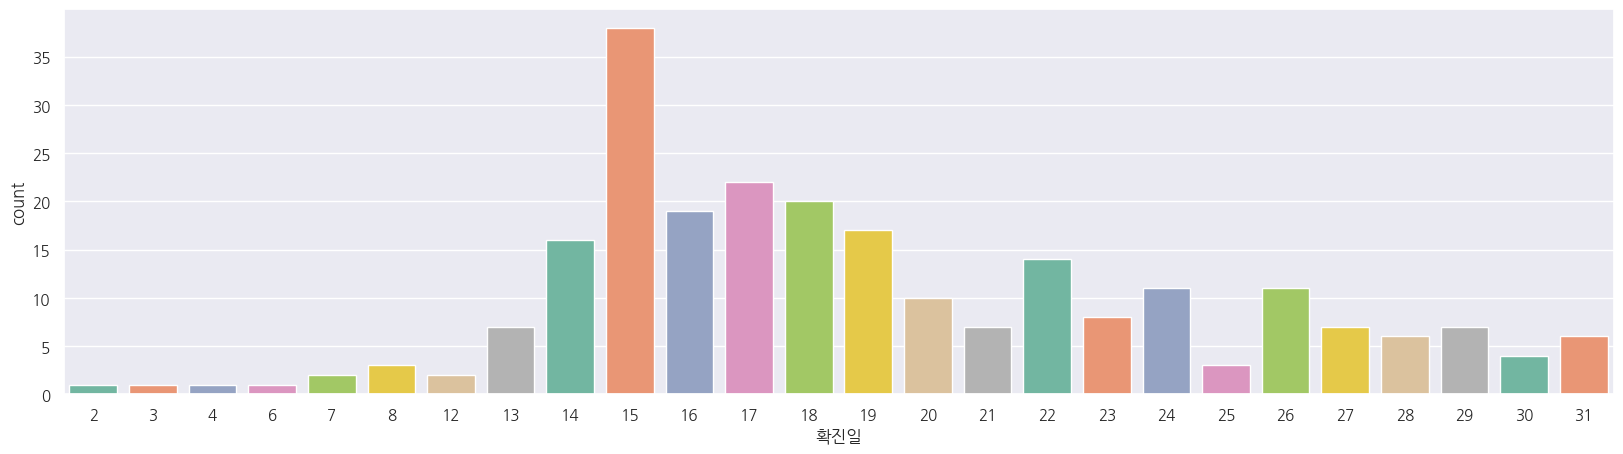

In [87]:
plt.figure(figsize=(20,5))
ax=sns.countplot(x='확진일', data=df_corona[(df_corona['확진달'] == 8) & (df_corona['지역'] == '성북구')],palette='Set2')

#### 3.2.4. 서울 지역에서 확진자를 지도에 출력

지도를 출력하기 위한 라이브러리로 folium을 사용해 봅시다.

In [88]:
# 지도 출력을 위한 라이브러리 folium을 import 합니다.
import folium

# Map 함수를 사용하여 지도를 출력합니다.
map_osm = folium.Map(location=[37.529622, 126.984307], zoom_start=11)# *|CH 18 # 최대 18

map_osm

지역마다 지도에 정보를 출력하기 위해서는 각 지역의 좌표정보가 필요합니다.

이를 해결하기 위해서 서울시 행정구역 시군 정보 데이터를 불러와 사용합니다.

데이터 출처: https://data.seoul.go.kr/dataList/OA-11677/S/1/datasetView.do

In [89]:
# CRS에 저장합니다.
#CRS=None
CRS=pd.read_csv("seoul_info.csv")
CRS.head()

,순번,시군구코드,시군구명_한글,시군구명_영문,ESRI_PK,위도,경도
0,1,11320,도봉구,Dobong-gu,0,37.665861,127.031767
1,2,11380,은평구,Eunpyeong-gu,1,37.617612,126.922700
2,3,11230,동대문구,Dongdaemun-gu,2,37.583801,127.050700
3,4,11590,동작구,Dongjak-gu,3,37.496504,126.944307
4,5,11545,금천구,Geumcheon-gu,4,37.460097,126.900155


In [90]:
# Dataframe을 출력해 봅니다.
CRS.head()

,순번,시군구코드,시군구명_한글,시군구명_영문,ESRI_PK,위도,경도
0,1,11320,도봉구,Dobong-gu,0,37.665861,127.031767
1,2,11380,은평구,Eunpyeong-gu,1,37.617612,126.922700
2,3,11230,동대문구,Dongdaemun-gu,2,37.583801,127.050700
3,4,11590,동작구,Dongjak-gu,3,37.496504,126.944307
4,5,11545,금천구,Geumcheon-gu,4,37.460097,126.900155


저장된 데이터에서 지역명이 `도봉구`인 데이터를 뽑아봅시다.

In [91]:
pass
CRS[CRS[ '시군구명_한글'] == '도봉구']

,순번,시군구코드,시군구명_한글,시군구명_영문,ESRI_PK,위도,경도
0,1,11320,도봉구,Dobong-gu,0,37.665861,127.031767


In [92]:
lat=CRS[CRS[ '시군구명_한글'] == '도봉구'][ '위도']
lo=CRS[CRS[ '시군구명_한글'] == '도봉구'][ '경도']
print(lat)
print (lo )

0    37.665861
Name: 위도, dtype: float64
0    127.031767
Name: 경도, dtype: float64


이제 for 문을 사용하여 지역마다 확진자를 원형 마커를 사용하여 지도에 출력해 봅시다.

In [93]:
df_corona.head(20)

,연번,확진달,확진일,환자번호,지역,여행력,접촉력,상태,이동경로,등록일,수정일,노출여부
0,5748,10,21,25530,양천구,NaN,감염경로 조사중,NaN,NaN,2020-10-22 10:58,2020-10-22 10:58,Y
1,5747,10,21,25528,강동구,NaN,강남서초 지인모임,NaN,NaN,2020-10-22 10:58,2020-10-22 10:58,Y
2,5746,10,21,25525,강남구,NaN,기타 확진자 접촉,NaN,NaN,2020-10-22 10:58,2020-10-22 10:58,Y
3,5745,10,21,25517,관악구,NaN,감염경로 조사중,NaN,NaN,2020-10-22 10:58,2020-10-22 10:58,Y
4,5744,10,21,25504,관악구,NaN,기타 확진자 접촉,NaN,NaN,2020-10-22 10:58,2020-10-22 10:58,Y
5,5743,10,21,25505,구로구,NaN,감염경로 조사중,NaN,NaN,2020-10-22 10:58,2020-10-22 15:44,Y
6,5742,10,21,25455,관악구,NaN,관악구 삼모스포렉스Ⅱ,NaN,NaN,2020-10-22 10:58,2020-10-22 10:58,Y
7,5741,10,21,25456,관악구,NaN,관악구 삼모스포렉스Ⅱ,NaN,NaN,2020-10-22 10:58,2020-10-22 10:58,Y
8,5740,10,21,25457,관악구,NaN,관악구 삼모스포렉스Ⅱ,NaN,NaN,2020-10-22 10:58,2020-10-22 10:58,Y
9,5739,10,21,25466,관악구,NaN,관악구 삼모스포렉스Ⅱ,NaN,NaN,2020-10-22 10:58,2020-10-22 10:58,Y


In [94]:
set(df_corona['지역'])

{'강남구',
 '강동구',
 '강북구',
 '강서구',
 '관악구',
 '광진구',
 '구로구',
 '금천구',
 '기타',
 '노원구',
 '도봉구',
 '동대문구',
 '동작구',
 '마포구',
 '서대문구',
 '서초구',
 '성동구',
 '성북구',
 '송파구',
 '양천구',
 '영등포구',
 '용산구',
 '은평구',
 '종로구',
 '중구',
 '중랑구',
 '타시도'}

In [95]:
pass

In [96]:
df_corona[df_corona['지역'] == '타시도'].index

Index([  20,   22,   41,   89,  137,  147,  155,  164,  178,  200,
       ...
       5640, 5662, 5685, 5699, 5707, 5710, 5714, 5730, 5736, 5740],
      dtype='int64', length=331)

In [97]:
df_corona.drop(df_corona[df_corona['지역'] == '타시도']. index)

,연번,확진달,확진일,환자번호,지역,여행력,접촉력,상태,이동경로,등록일,수정일,노출여부
0,5748,10,21,25530,양천구,NaN,감염경로 조사중,NaN,NaN,2020-10-22 10:58,2020-10-22 10:58,Y
1,5747,10,21,25528,강동구,NaN,강남서초 지인모임,NaN,NaN,2020-10-22 10:58,2020-10-22 10:58,Y
2,5746,10,21,25525,강남구,NaN,기타 확진자 접촉,NaN,NaN,2020-10-22 10:58,2020-10-22 10:58,Y
3,5745,10,21,25517,관악구,NaN,감염경로 조사중,NaN,NaN,2020-10-22 10:58,2020-10-22 10:58,Y
4,5744,10,21,25504,관악구,NaN,기타 확진자 접촉,NaN,NaN,2020-10-22 10:58,2020-10-22 10:58,Y
...,...,...,...,...,...,...,...,...,...,...,...,...
5743,5,1,31,9,성북구,NaN,#5 접촉,퇴원,이동경로 공개기간 경과,2020-10-22 10:58,2020-10-23 9:00,Y
5744,4,1,30,7,마포구,중국 우한시,해외 접촉,퇴원,이동경로 공개기간 경과,2020-10-22 10:58,2020-10-23 9:00,Y
5745,3,1,30,6,종로구,NaN,#3 접촉,퇴원,이동경로 공개기간 경과,2020-10-22 10:58,2020-10-23 9:00,Y
5746,2,1,30,5,중랑구,중국 우한시,해외 접촉,퇴원,이동경로 공개기간 경과,2020-10-22 10:58,2020-10-23 9:00,Y


In [98]:
#지역 확인
pass

In [99]:
corona_seoul = df_corona.drop(df_corona[df_corona['지역']== '타시도'].index)
corona_seoul = corona_seoul.drop(corona_seoul[corona_seoul['지역'] == '기타'].index)

In [100]:
corona_seoul.head()

,연번,확진달,확진일,환자번호,지역,여행력,접촉력,상태,이동경로,등록일,수정일,노출여부
0,5748,10,21,25530,양천구,NaN,감염경로 조사중,NaN,NaN,2020-10-22 10:58,2020-10-22 10:58,Y
1,5747,10,21,25528,강동구,NaN,강남서초 지인모임,NaN,NaN,2020-10-22 10:58,2020-10-22 10:58,Y
2,5746,10,21,25525,강남구,NaN,기타 확진자 접촉,NaN,NaN,2020-10-22 10:58,2020-10-22 10:58,Y
3,5745,10,21,25517,관악구,NaN,감염경로 조사중,NaN,NaN,2020-10-22 10:58,2020-10-22 10:58,Y
4,5744,10,21,25504,관악구,NaN,기타 확진자 접촉,NaN,NaN,2020-10-22 10:58,2020-10-22 10:58,Y


In [101]:
pass

In [102]:
pass

In [103]:
CRS.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   순번       25 non-null     int64  
 1   시군구코드    25 non-null     int64  
 2   시군구명_한글  25 non-null     object 
 3   시군구명_영문  25 non-null     object 
 4   ESRI_PK  25 non-null     int64  
 5   위도       25 non-null     float64
 6   경도       25 non-null     float64
dtypes: float64(2), int64(3), object(2)
memory usage: 1.5+ KB


In [104]:
corona_seoul = df_corona.drop(df_corona[df_corona['지역'] == '타시도'].index)
corona_seoul= corona_seoul.drop(corona_seoul[corona_seoul['지역'] == '기타'].index)
# 서울 가운데 좌표를 잡아 지도를 출력합니다.
map_osm = folium.Map(location=[37.529622, 126.984307],
zoom_start=12)
# 지역 정보를 set 함수를 사용하여 25개 고유의 지역을 뽑아냅니다.
for region in set(corona_seoul['지역']):
  # 해당 지역의 데이터 개수를 count에 저장합니다.
  count = len(corona_seoul[corona_seoul['지역'] == region])
# 해당 지역의 데이터를 CRS에서 뽑아냅니다.
CRS_region = CRS[CRS['시군구명_한글'] == region]
lat = float(CRS_region['위도'])
Ing = float(CRS_region['경도'])
# # CircleMarker를 사용하여 지역마다 원형마커를 생성합니다.
if region == '관악구' :
  folium.CircleMarker(location=[lat, Ing], # 위치
                      radius=count/5 + 10,
                      fill=True,
                      fill_color='red').add_to(map_osm)

else :
  folium.CircleMarker(location=[lat, Ing], # 위치
                      radius=count/5 + 10,
                      fill=True,
                      fill_color='green').add_to(map_osm)

map_osm

/tmp/ipykernel_5339/2086324888.py:12: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  lat = float(CRS_region['위도'])
/tmp/ipykernel_5339/2086324888.py:13: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  Ing = float(CRS_region['경도'])


In [128]:
# 서울 가운데 좌표를 잡아 지도를 출력합니다.
map_osm = folium.Map(location=[37.529622, 126.984307], zoom_start=12)

# 지역 정보를 set 함수를 사용하여 25개 고유의 지역을 뽑아냅니다.
for region in set(corona_seoul['지역']):

    # 해당 지역의 데이터 개수를 count에 저장합니다.
    count = len(corona_seoul[corona_seoul['지역'] == region])

    # 해당 지역의 데이터를 CRS에서 뽑아냅니다.
    CRS_region = CRS[CRS['시군구명_한글'] == region]

    # [수정 1] CRS_region에 데이터가 없을 경우를 대비한 예외 처리 추가
    if CRS_region.empty:
        continue

    # [수정 2] 컬럼명 좌우에 있던 불필요한 공백(' 위 도 ', ' 경도 ')을 제거했습니다.
    # [수정 3] 여러 행이 나올 경우를 대비해 .iloc[0]을 추가하여 첫 번째 행의 값을 가져옵니다.
    lat = float(CRS_region['위도'].iloc[0])
    lng = float(CRS_region['경도'].iloc[0])

    # CircleMarker를 사용하여 지역마다 원형마커를 생성합니다.
    if region == '관악구':
        color = 'red'
    else:
        color = 'green'

    # [수정 4] Ing(대문자 I)로 되어 있던 오타를 lng(소문자 l)로 수정했습니다.
    # [수정 5] 원래 주석의 의도대로 folium.Marker 대신 folium.CircleMarker를 사용하고 색상(color) 옵션을 적용했습니다.
    folium.CircleMarker(
        location=[lat, lng],
        radius=count * 0.2,  # 데이터 개수에 따라 원 크기 조절 (필요시 배수 조절)
        color=color,
        fill=True,
        fill_color=color,
        tooltip=region + "(" + str(count) + ")"
    ).add_to(map_osm)

# 지도 출력
map_osm

In [106]:
# df_corona의 지역에는 'oo구' 이외로 `타시도`, `기타`에 해당되는 데이터가 존재 합니다.
# 위 데이터에 해당되는 위도, 경도를 찾을 수 없기에 삭제하여 corona_seoul로 저장합니다.
corona_seoul = pass
corona_seoul = pass

# 서울 가운데 좌표를 잡아 지도를 출력합니다.
map_osm = pass

# 지역 정보를 set 함수를 사용하여 25개 고유의 지역을 뽑아냅니다.
for region in set(pass):

    # 해당 지역의 데이터 개수를 count에 저장합니다.
    count = pass

    # 해당 지역의 데이터를 CRS에서 뽑아냅니다.
    CRS_region = pass
    lat = pass
    lng = pass
    pass
    pass
     # CircleMarker를 사용하여 지역마다 원형마커를 생성합니다.

    folium.CircleMarker(location=pass, # 위치
                       radius=pass,
                       fill=pass,
                      fill_color=pass).add_to(map_osm)

map_osm

SyntaxError: invalid syntax (467442988.py, line 3)

In [107]:
# 서울 가운데 좌표를 잡아 지도를 출력합니다.
map_osm = pass


# 지역 정보를 set 함수를 사용하여 25개 고유의 지역을 뽑아냅니다.
for region in set(pass):

    # 해당 지역의 데이터 개수를 count에 저장합니다.
    count = pass
    # 해당 지역의 데이터를 CRS에서 뽑아냅니다.
    CRS_region = pass
    lat = pass
    lng = pass

    pass

map_osm

SyntaxError: invalid syntax (3699294189.py, line 2)

### 3.3. 여행력

`여행력` 데이터를 간단히 출력해보면 `NaN`과 해외 지역명의 문자열 데이터임을 알 수 있습니다.

In [108]:
df_corona['여행력']

,여행력
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
5743,NaN
5744,중국 우한시
5745,NaN
5746,중국 우한시


In [109]:
df_corona[ '여행력'].isnull().sum()

np.int64(5290)

In [110]:
df_corona[ '여행력'][df_corona['여행력'].isnull() == False].tail(50)

,여행력
5431,필리핀 마닐라
5434,캐나다
5435,미국 캐나다
5439,필리핀
5440,스페인 카타르
5442,미국
5443,필리핀
5444,미국
5445,필리핀
5446,미국


In [127]:
df_corona[ '여행력'][df_corona[ '여행력'].isnull() == False].tail(50)

,여행력
5431,필리핀 마닐라
5434,캐나다
5435,미국 캐나다
5439,필리핀
5440,스페인 카타르
5442,미국
5443,필리핀
5444,미국
5445,필리핀
5446,미국


#### 3.3.1. 여행력 있다 vs 없다 출력

먼저 여행력이 있는 사람과 없는 사람이 어느 정도인지를 비교해 보겠습니다.

여행력이 없는 사람은 `NaN`에 해당되는 사람으로 비어있는 데이터의 수를 세어 계산합니다.

In [112]:
df_corona.isnull()

,연번,확진달,확진일,환자번호,지역,여행력,접촉력,상태,이동경로,등록일,수정일,노출여부
0,False,False,False,False,False,True,False,True,True,False,False,False
1,False,False,False,False,False,True,False,True,True,False,False,False
2,False,False,False,False,False,True,False,True,True,False,False,False
3,False,False,False,False,False,True,False,True,True,False,False,False
4,False,False,False,False,False,True,False,True,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
5743,False,False,False,False,False,True,False,False,False,False,False,False
5744,False,False,False,False,False,False,False,False,False,False,False,False
5745,False,False,False,False,False,True,False,False,False,False,False,False
5746,False,False,False,False,False,False,False,False,False,False,False,False


In [113]:
# isnull 함수를 사용하여 여행력이 없는 사람들의 수를 계산합니다.
sum_travel_no = sum(df_corona[ '여행력'].isnull())
print(f"여행력이 없는 사람의 수: {sum_travel_no}")

여행력이 없는 사람의 수: 5290


In [114]:
# 전체 샘플 수를 구합니다.
sum_travel_all = len(df_corona[ '여행력'])
print("전체 확진자 수: {}".format(sum_travel_all))

# 여행력이 있는 사람들의 수를 계산합니다.
sum_travel_yes = sum_travel_all - sum_travel_no
print("여행력이 있는 사람의 수: {}".format(sum_travel_yes))

전체 확진자 수: 5748
여행력이 있는 사람의 수: 458


<BarContainer object of 2 artists>

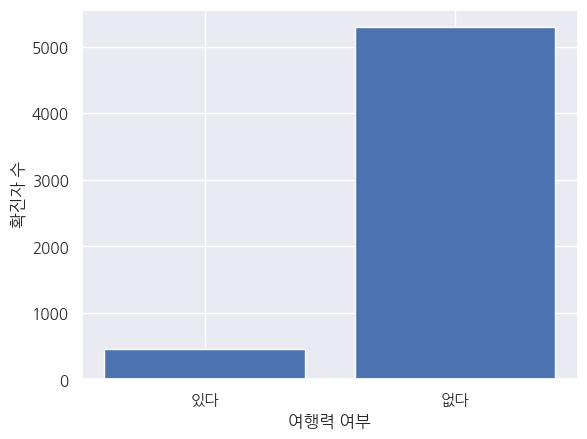

In [115]:
# matplotlib의 bar 함수를 사용하여 막대 그래프를 출력합니다.
# 한글 출력을 위한 세팅을 합니다.
plt.rc('font', family="NanumGothic")

# x축, y축 명칭을 설정합니다.
plt.ylabel('확진자 수')
plt.xlabel('여행력 여부')

# 그래프 x축에 해당되는 데이터와 y축에 해당되는 데이터를 list 형태로 입력합니다.
plt.bar(['있다', '없다'], [sum_travel_yes, sum_travel_no])

#### 3.3.2. 여행지 분포 출력

이번에는 어떠한 여행지들이 있는 그 분포를 출력해 봅시다.

먼저 459개의 여행지 데이터에서 중복을 제외한 모든 종류의 여행지를 출력해 봅시다.

In [116]:
# set 함수를 사용하여 중복을 제외한 여행지를 출력합니다.
set(df_corona[ '여행력'])

{'UAE',
 nan,
 '나이지리아',
 '네팔',
 '독일',
 '독일프랑스',
 '러시아',
 '말레이시아',
 '멕시코',
 '멕시코 미국',
 '모로코 터키',
 '모로코 프랑스 오스트리아',
 '몰타',
 '미국',
 '미국 뉴욕',
 '미국 멕시코',
 '미국 브라질',
 '미국 캐나다',
 '미국 캐나다 멕시코',
 '방글라데시',
 '베트남',
 '브라질',
 '브라질 아르헨티아 칠레 볼리비아',
 '사우디아라비아',
 '스페인',
 '스페인 카타르',
 '스페인 프랑스',
 '스페인체코',
 '싱가포르',
 '아랍에미리트',
 '아르헨티나 볼리비아 브라질',
 '아일랜드',
 '에콰도르',
 '에티오피아',
 '영국',
 '영국 프랑스',
 '오스트리아',
 '요르단',
 '우간다',
 '우즈베키스탄',
 '우크라이나',
 '우한 교민',
 '우한교민',
 '이라크',
 '이란',
 '이집트',
 '이탈리아',
 '이탈리아 독일 홍콩',
 '이탈리아 프랑스',
 '인도',
 '인도네시아',
 '일본',
 '중국',
 '중국 우한시',
 '중국 청도',
 '체코',
 '체코 헝가리 오스트리아 이탈리아 프랑스',
 '카자흐스탄',
 '카타르',
 '캐나다',
 '케냐',
 '콩코 프랑스',
 '쿠웨이트',
 '키르기스스탄',
 '키르기즈스탄',
 '태국',
 '터키',
 '파라과이',
 '파키스탄',
 '팔라우',
 '페루',
 '페루 미국',
 '포르투칼',
 '폴란드',
 '프랑스',
 '프랑스 독일',
 '프랑스 스페인',
 '프랑스 스페인 독일 이탈리아 네덜란드',
 '필리핀',
 '필리핀 마닐라',
 '호주 인도네시아',
 '홍콩'}

`value_counts` 함수를 사용하여 도수 분포표를 출력합니다.

In [117]:
# 출력 결과를 모두 볼 수 있도록 세팅합니다.
#pd.set_option('display.max_rows', None)

# value_counts 함수를 사용하여 도수 분포표를 출력합니다.
df_corona[ '여행력'].value_counts()

,count
여행력,
미국,153
영국,50
필리핀,25
프랑스,13
우즈베키스탄,13
...,...
스페인 프랑스,1
중국 청도,1
우한교민,1


위 결과는 여러 나라의 여행력이 있는 사람들의 결과를 고려하지 않았습니다.

예를 들어 `이탈리아 프랑스` 데이터의 경우와 `이탈리아`는 다른 값으로 고려되어 따로 도수를 계산하게 됩니다.

따라서 나라별로 도수를 구하기 위해서 아래와 같은 코드를 사용합니다.

In [118]:
pass

In [119]:
list_country = []
for country in df_corona['여행력']:
  if type(country) == str:
    list_country = list_country + country.split(' ')

se_country = pd.Series(list_country)
se_country.value_counts()

,count
미국,161
영국,51
필리핀,27
프랑스,24
스페인,16
...,...
독일프랑스,1
우한교민,1
싱가포르,1
우한,1


### 3.4. 접촉력

`접촉력` 데이터를 출력해보면 코로나를 접촉한 방식을 설명하는 문자열 데이터임을 알 수 있습니다.

In [120]:
df_corona['접촉력']

,접촉력
0,감염경로 조사중
1,강남서초 지인모임
2,기타 확진자 접촉
3,감염경로 조사중
4,기타 확진자 접촉
...,...
5743,#5 접촉
5744,해외 접촉
5745,#3 접촉
5746,해외 접촉


#### 3.4.1. 접촉력 도수분포표

확진자의 접촉력은 다양하게 기록되었습니다.

도수분포표를 사용하여 정리해 봅시다.

In [121]:
pass

### 3.5. 상태

`접촉력` 데이터를 출력해보면 현재 환자 상태를 확인할 수 있는 문자열 데이터임을 알 수 있습니다.

In [122]:
pass

In [123]:
pass

In [124]:
set()

set()

#### 3.5.1. 상태별 확진자 수 출력

데이터가 어떻게 이루어져 있는지 정확히 알기 위하여 중복을 제외한 모든 종류의 상태를 출력해 봅시다.

In [125]:
pass

각 상태에 따른 확진자 수를 계산하여 봅시다.

In [126]:
sum_status_death = pass
print(f"사망자 수: {sum_status_death}")

sum_status_discharge = pass
print("퇴원자 수: {}".format(pass))

sum_status_nan = pass
print("상태를 알 수 없는 사람들의 수: {}".format(pass))

SyntaxError: invalid syntax (3834548103.py, line 1)

최종적으로 상태에 따른 확진자 수를 막대 그래프로 표현해 봅시다.

In [ ]:
plt.rc('font', family="NanumGothic")
plt.ylabel('확진자 수')
plt.xlabel('상태')
pass

### 3.6. 노출여부

`노출여부` 데이터를 출력해보면 `Y`값만 가지고 있는 문자열 데이터임을 알 수 있습니다.

In [ ]:
pass

In [ ]:
pass